## Homework 3: Supervised Learning

### Exercise 3: Evaluation Metrics on a Synthetic Dataset

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
np.random.seed(0)

def make_toy_2d_dataset(n0=200, n1=200, mu0=(-2, -2), mu1=(2, 2), var0=1.0, var1=0.5):
    X0 = np.random.normal(loc=mu0, scale=np.sqrt(var0), size=(n0, 2))
    X1 = np.random.normal(loc=mu1, scale=np.sqrt(var1), size=(n1, 2))
    y0 = np.zeros((n0, 1), dtype=int)
    y1 = np.ones((n1, 1), dtype=int)

    X_raw = np.vstack([X0, X1])
    y = np.vstack([y0, y1])

    X = np.hstack([X_raw, np.ones((X_raw.shape[0], 1))])

    return X_raw, X, y

X_raw, X, y = make_toy_2d_dataset(n0=200, n1=200)

In [13]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def L(theta, X, y):
    theta = np.asarray(theta).reshape(-1, 1)
    p = sigmoid(X @ theta)
    eps = 1e-12
    return float(-(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)).mean())

def grad_L(theta, X, y):
    theta = np.asarray(theta).reshape(-1, 1)
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / X.shape[0]

def accuracy(theta, X, y, threshold=0.5):
    theta = np.asarray(theta).reshape(-1, 1)
    p = sigmoid(X @ theta)
    preds = (p >= threshold).astype(int)
    return float((preds == y).mean())

In [14]:
def gradient_descent(theta0, eta0, maxit, tolL, toltheta, X, y):
    theta = np.asarray(theta0, dtype=float).reshape(-1, 1).copy()
    thetas = [theta.copy()]
    losses = [L(theta, X, y)]
    accs = [accuracy(theta, X, y)]

    for it in range(maxit):
        g = grad_L(theta, X, y)

        if np.linalg.norm(g) < tolL:
            break

        theta_next = theta - eta0 * g

        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L(theta, X, y))
            accs.append(accuracy(theta, X, y))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L(theta, X, y))
        accs.append(accuracy(theta, X, y))

    return theta, it, thetas, losses, accs

In [15]:
def stochastic_gradient_descent(L, grad_L, X, y, Theta0, lr=1e-2, batch_size=32, epochs=200):
    Theta = np.asarray(Theta0, dtype=float).reshape(-1, 1).copy()
    N = X.shape[0]

    thetas = [Theta.copy()]
    losses = [L(Theta, X, y)]
    accs = [accuracy(Theta, X, y)]

    for epoch in range(epochs):
        idx = np.random.permutation(N)

        for start in range(0, N, batch_size):
            batch_idx = idx[start:start + batch_size]
            g = grad_L(Theta, X[batch_idx], y[batch_idx])
            Theta = Theta - lr * g
            thetas.append(Theta.copy())

        losses.append(L(Theta, X, y))
        accs.append(accuracy(Theta, X, y))

    return Theta, epoch, thetas, losses, accs

In [16]:
def plot_training_curves(losses, accs, title_prefix=""):
    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(5)
    fig.set_figwidth(12)
    fig.suptitle(title_prefix, fontsize=14)

    axs[0].plot(losses)
    axs[0].set_title("Loss vs epoch/iteration")
    axs[0].set_xlabel("epoch/iteration")
    axs[0].set_ylabel("loss")

    axs[1].plot(accs)
    axs[1].set_title("Accuracy vs epoch/iteration")
    axs[1].set_xlabel("epoch/iteration")
    axs[1].set_ylabel("accuracy")

    plt.show()
    
def plot_dataset_and_boundary(theta, X_raw, y, title="Decision Boundary"):
    theta = np.asarray(theta).reshape(-1)
    t1, t2, b = float(theta[0]), float(theta[1]), float(theta[2])

    plt.figure(figsize=(7, 6))
    plt.scatter(X_raw[y[:, 0] == 0, 0], X_raw[y[:, 0] == 0, 1], s=15, label="Class 0")
    plt.scatter(X_raw[y[:, 0] == 1, 0], X_raw[y[:, 0] == 1, 1], s=15, label="Class 1")

    x_min, x_max = X_raw[:, 0].min() - 1.0, X_raw[:, 0].max() + 1.0
    xs = np.linspace(x_min, x_max, 200)

    # handle vertical boundary if t2 is 0
    if abs(t2) < 1e-12:
        # t1*x + b = 0 -> x = -b/t1
        if abs(t1) > 1e-12:
            x_line = -b / t1
            plt.axvline(x_line)
    else:
        ys = -(t1 * xs + b) / t2
        plt.plot(xs, ys, linewidth=2)

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

In [17]:
def predict_proba(theta, X):
    theta = np.asarray(theta).reshape(-1, 1)
    return sigmoid(X @ theta)

def predict_label(proba, threshold=0.5):
    return (proba >= threshold).astype(int)

def confusion_counts(y_true, y_pred):
    y_true = y_true.astype(int).reshape(-1, 1)
    y_pred = y_pred.astype(int).reshape(-1, 1)
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    return TP, FP, FN, TN

def metrics_from_counts(TP, FP, FN, TN):
    eps = 1e-12
    acc = (TP + TN) / (TP + FP + FN + TN + eps)
    prec = TP / (TP + FP + eps)
    rec = TP / (TP + FN + eps)
    f1 = 2 * prec * rec / (prec + rec + eps)
    return acc, prec, rec, f1

In [18]:
def evaluate_thresholds(theta, X, y, thresholds=(0.5, 0.3, 0.7)):
    proba = predict_proba(theta, X)
    print("thr |  TP   FP   FN   TN |  acc    prec   recall   f1")
    for t in thresholds:
        y_pred = predict_label(proba, threshold=t)
        TP, FP, FN, TN = confusion_counts(y, y_pred)
        acc, prec, rec, f1 = metrics_from_counts(TP, FP, FN, TN)
        print(f"{t:>3.1f} | {TP:>4} {FP:>4} {FN:>4} {TN:>4} | {acc:>6.3f}  {prec:>6.3f}  {rec:>6.3f}  {f1:>6.3f}")

Full GD
iters: 2000
final theta: [ 2.23867662  2.30701414 -0.38920359]
final loss: 0.003691
final acc:  100.00%


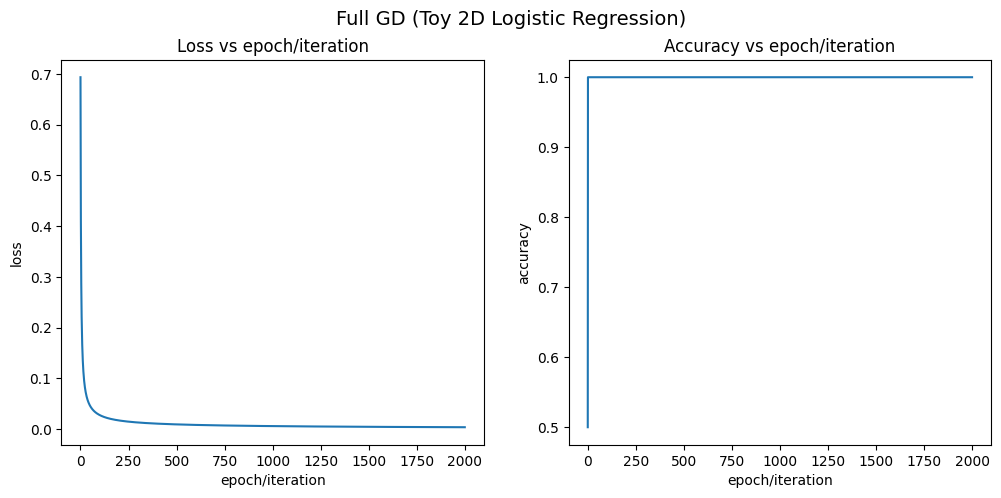

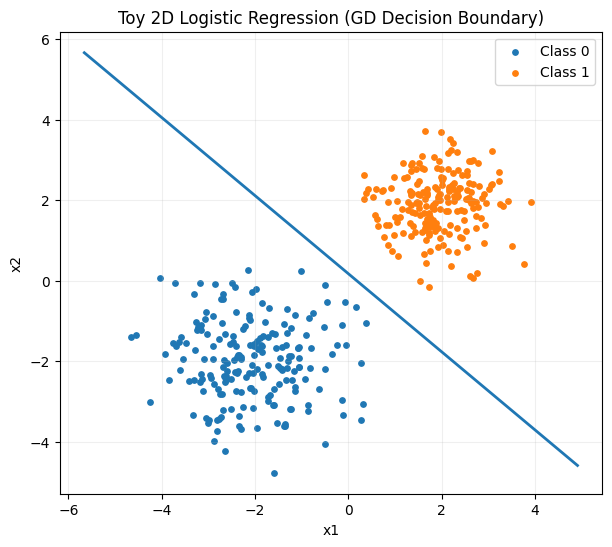


 Metrics for GD model (thresholds 0.5 / 0.3 / 0.7) 
thr |  TP   FP   FN   TN |  acc    prec   recall   f1
0.5 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.3 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.7 |  200    0    0  200 |  1.000   1.000   1.000   1.000


In [19]:
d = X.shape[1]
theta0 = np.zeros((d, 1))
eta_gd = 1e-1
maxit = 2000
tolL = 1e-6
toltheta = 1e-8

theta_gd, it_gd, thetas_gd, losses_gd, accs_gd = gradient_descent(
    theta0=theta0, eta0=eta_gd, maxit=maxit, tolL=tolL, toltheta=toltheta, X=X, y=y
)

print("Full GD")
print("iters:", len(thetas_gd) - 1)
print("final theta:", theta_gd.reshape(-1))
print(f"final loss: {losses_gd[-1]:.6f}")
print(f"final acc:  {accs_gd[-1]*100:.2f}%")

plot_training_curves(losses_gd, accs_gd, title_prefix="Full GD (Toy 2D Logistic Regression)")
plot_dataset_and_boundary(theta_gd, X_raw, y, title="Toy 2D Logistic Regression (GD Decision Boundary)")

print("\n Metrics for GD model (thresholds 0.5 / 0.3 / 0.7) ")
evaluate_thresholds(theta_gd, X, y, thresholds=(0.5, 0.3, 0.7))


 SGD (batch_size=1) 
epochs: 200
final theta: [ 2.9324311   3.06490904 -0.85460499]
final loss: 0.001332
final acc:  100.00%


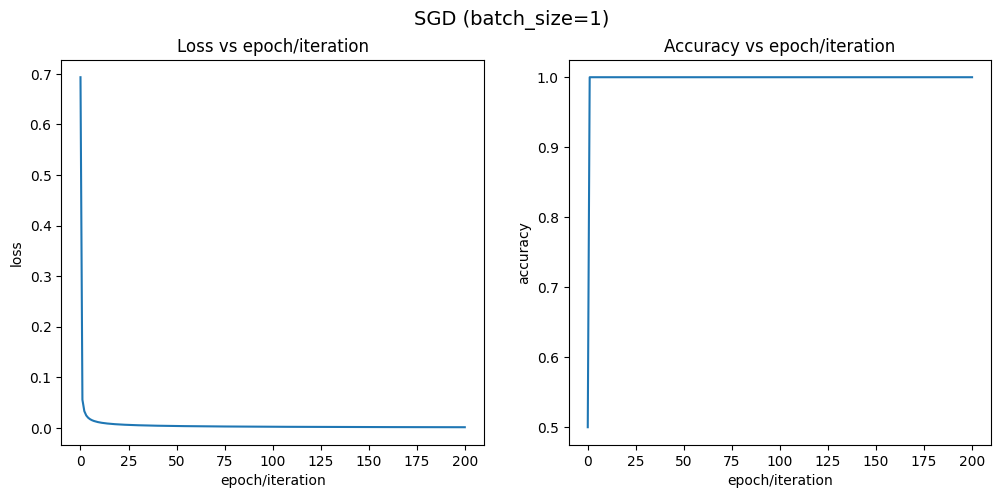

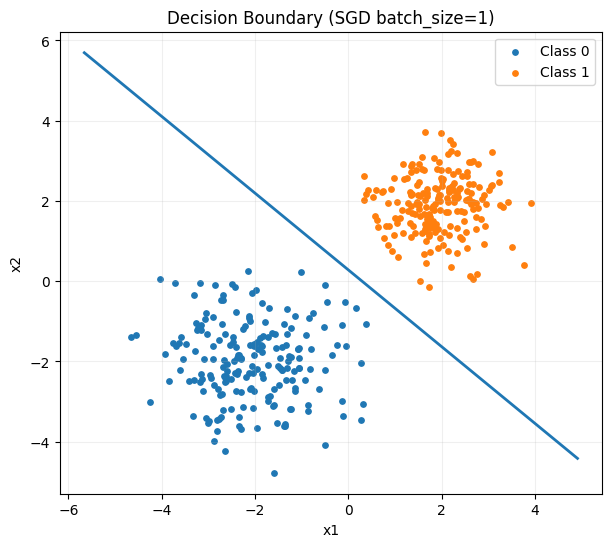


 Metrics for SGD batch_size=1 (thresholds 0.5 / 0.3 / 0.7) 
thr |  TP   FP   FN   TN |  acc    prec   recall   f1
0.5 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.3 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.7 |  200    0    0  200 |  1.000   1.000   1.000   1.000

 SGD (batch_size=10) 
epochs: 200
final theta: [ 1.86012325  1.88569519 -0.19163261]
final loss: 0.006826
final acc:  100.00%


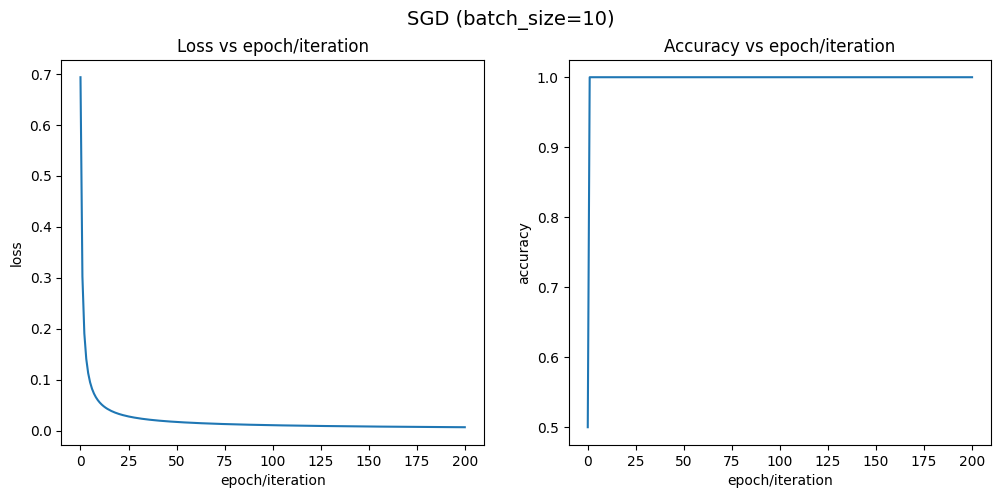

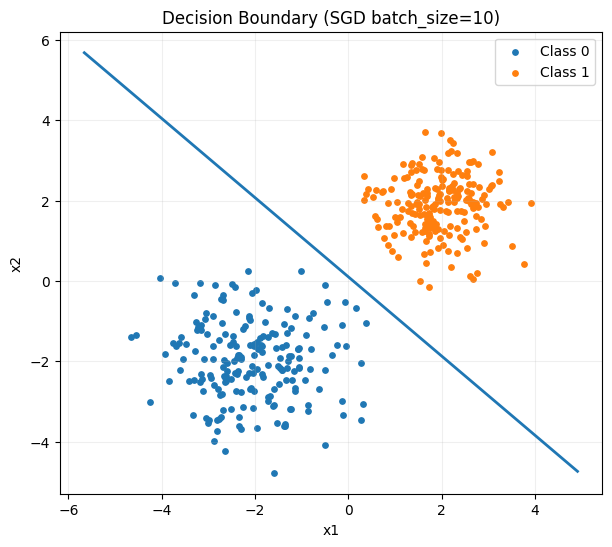


 Metrics for SGD batch_size=10 (thresholds 0.5 / 0.3 / 0.7) 
thr |  TP   FP   FN   TN |  acc    prec   recall   f1
0.5 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.3 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.7 |  200    0    0  200 |  1.000   1.000   1.000   1.000

 SGD (batch_size=400) 
epochs: 200
final theta: [0.664875   0.64944227 0.00419523]
final loss: 0.094765
final acc:  100.00%


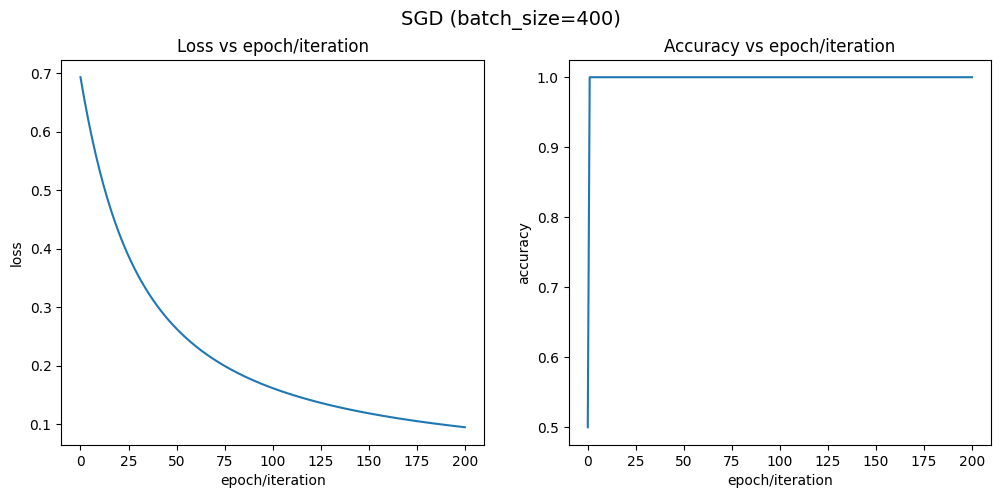

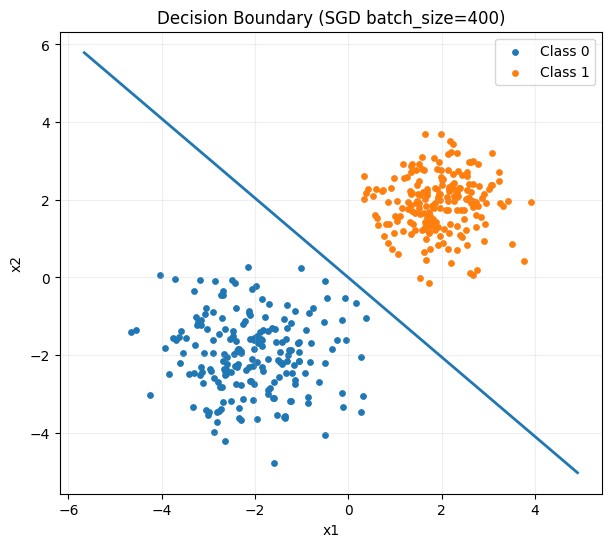


 Metrics for SGD batch_size=400 (thresholds 0.5 / 0.3 / 0.7) 
thr |  TP   FP   FN   TN |  acc    prec   recall   f1
0.5 |  200    0    0  200 |  1.000   1.000   1.000   1.000
0.3 |  200    7    0  193 |  0.982   0.966   1.000   0.983
0.7 |  200    0    0  200 |  1.000   1.000   1.000   1.000


In [20]:
batch_sizes = [1, 10, X.shape[0]]
lr = 1e-2
epochs = 200

results = {}
for bs in batch_sizes:
    theta_sgd, ep_last, thetas_sgd, losses_sgd, accs_sgd = stochastic_gradient_descent(
        L=L, grad_L=grad_L, X=X, y=y, Theta0=theta0, lr=lr, batch_size=bs, epochs=epochs
    )
    results[bs] = (theta_sgd, thetas_sgd, losses_sgd, accs_sgd)

    print(f"\n SGD (batch_size={bs}) ")
    print("epochs:", epochs)
    print("final theta:", theta_sgd.reshape(-1))
    print(f"final loss: {losses_sgd[-1]:.6f}")
    print(f"final acc:  {accs_sgd[-1]*100:.2f}%")

    plot_training_curves(losses_sgd, accs_sgd, title_prefix=f"SGD (batch_size={bs})")
    plot_dataset_and_boundary(theta_sgd, X_raw, y, title=f"Decision Boundary (SGD batch_size={bs})")

    print(f"\n Metrics for SGD batch_size={bs} (thresholds 0.5 / 0.3 / 0.7) ")
    evaluate_thresholds(theta_sgd, X, y, thresholds=(0.5, 0.3, 0.7))